# CIFAR-10 Regression Experiment: FCN vs SCN

**Goal**: Compare generalisation of FCN (full image) vs SCN (sliding-window patches)
on a regression task whose ground truth has local structure.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import uniform_filter1d
from torchvision import datasets, transforms
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

PLOT_CONFIG = {
    'title_fontsize': 18,
    'label_fontsize': 18,
    'tick_fontsize': 14,
    'legend_fontsize': 14,
    'linewidth': 2.5,
    'markersize': 12,
    'single_fig_size': (6, 5),
    'double_fig_size': (12, 5),
    'grid_alpha': 0.3,
    'dpi': 300,
}

plt.rcParams.update({
    'font.size': PLOT_CONFIG['tick_fontsize'],
    'axes.titlesize': PLOT_CONFIG['title_fontsize'],
    'axes.labelsize': PLOT_CONFIG['label_fontsize'],
    'xtick.labelsize': PLOT_CONFIG['tick_fontsize'],
    'ytick.labelsize': PLOT_CONFIG['tick_fontsize'],
    'legend.fontsize': PLOT_CONFIG['legend_fontsize'],
    'figure.dpi': PLOT_CONFIG['dpi'],
    'lines.linewidth': PLOT_CONFIG['linewidth'],
    'lines.markersize': PLOT_CONFIG['markersize'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

COLORS = {
    'train': '#D55E00',
    'excess': '#0072B2',
    'FCN_train': '#E74C3C',
    'FCN_excess': '#C0392B',
    'SCN_train': '#3498DB',
    'SCN_excess': '#2874A6',
    'initial': '#0072B2',
    'final': '#D55E00',
}

def decimal_tick_formatter(x, pos):
    if x == 0:
        return '0'
    elif abs(x) >= 1:
        return f'{x:.1f}'
    elif abs(x) >= 0.1:
        return f'{x:.2f}'
    elif abs(x) >= 0.01:
        return f'{x:.3f}'
    else:
        return f'{x:.4f}'

def thousands_formatter(x, pos):
    if x == 0:
        return '0'
    elif x >= 1000:
        return f'{int(x/1000)}k'
    else:
        return f'{int(x)}'

def smooth(arr, window=50):
    return uniform_filter1d(arr, size=window)

SAVE_DIR = 'figures/cifar_fcn_scn'
import os; os.makedirs(SAVE_DIR, exist_ok=True)
print("Config loaded.")


Device: cuda
Config loaded.


## Config

In [2]:
DATA_CONFIG = {
    'n_train': 1024,
    'n_test': 10000,
    'sigma': 1.0,
}

SEEDS = [42]
N_SEEDS = len(SEEDS)

MODEL_CONFIG = {
    'd': 3072,
    'm': 27,
    'L': 900,
    'K_fcn': 1024,
    'K_scn': 1024,
    'img_size': 32,
    'patch_size': 3,
    'stride': 1,
    'n_channels': 3,
}

K_TRUE = 20

fcn_params = MODEL_CONFIG['K_fcn'] * (MODEL_CONFIG['d'] + 2) + 1
scn_params  = MODEL_CONFIG['K_scn']  * (MODEL_CONFIG['m'] + 2) + 1

print(f"Parameter Counts (K=1024 for both):")
print(f"  FCN: K={MODEL_CONFIG['K_fcn']}, params={fcn_params:,}")
print(f"  SCN: K={MODEL_CONFIG['K_scn']},  params={scn_params:,}")
print(f"  FCN has {fcn_params / scn_params:.1f}x more params than SCN")

TRAIN_CONFIG = {
    'lr': 0.2,
    'epochs': 5000,
    'grad_clip': 2,
    'log_every': 2000,
    'hessian_freq': 500,
    'checkpoint_freq': 500,   # save model every N epochs
}

CKPT_DIR = f'{SAVE_DIR}/checkpoints'
import os; os.makedirs(CKPT_DIR, exist_ok=True)

print("\n" + "="*60)
print("CIFAR-10 REGRESSION EXPERIMENT (Local Structure)")
print("="*60)
print(f"  n_train : {DATA_CONFIG['n_train']}")
print(f"  sigma   : {DATA_CONFIG['sigma']} (σ² = {DATA_CONFIG['sigma']**2})")
print(f"  K_TRUE  : {K_TRUE}")
print(f"  m={MODEL_CONFIG['m']}, L={MODEL_CONFIG['L']}, patch={MODEL_CONFIG['patch_size']}x{MODEL_CONFIG['patch_size']}, stride={MODEL_CONFIG['stride']}")
print(f"  lr={TRAIN_CONFIG['lr']}, epochs={TRAIN_CONFIG['epochs']}")
print(f"  checkpoints → {CKPT_DIR}/")
print("="*60)


Parameter Counts (K=1024 for both):
  FCN: K=1024, params=3,147,777
  SCN: K=1024,  params=29,697
  FCN has 106.0x more params than SCN

CIFAR-10 REGRESSION EXPERIMENT (Local Structure)
  n_train : 1024
  sigma   : 1.0 (σ² = 1.0)
  K_TRUE  : 20
  m=27, L=900, patch=3x3, stride=1
  lr=0.2, epochs=5000
  checkpoints → figures/cifar_fcn_scn/checkpoints/


## Data Loading (Local Structure Ground Truth)

Generate regression targets using a ground truth SCN function:
- f*(x) = (1/L) Σ_l Σ_k a_k · ReLU(⟨w_k, x_l⟩)
- y = f*(x) + N(0, σ²)

In [3]:
def create_sliding_window_indices(img_size, patch_size, stride, n_channels):
    """
    Create indices for sliding window patches.
    
    Args:
        img_size: Image size (assumes square)
        patch_size: Patch size (assumes square)
        stride: Stride for sliding window
        n_channels: Number of channels
    
    Returns:
        H: (L, m) tensor of indices where L = num_patches, m = patch_size^2 * n_channels
    """
    m = patch_size * patch_size * n_channels
    patches_per_side = (img_size - patch_size) // stride + 1
    L = patches_per_side * patches_per_side
    
    H = torch.zeros(L, m, dtype=torch.long)
    
    patch_idx = 0
    for pi in range(patches_per_side):
        for pj in range(patches_per_side):
            row_start = pi * stride
            col_start = pj * stride
            
            indices = []
            for c in range(n_channels):
                for i in range(patch_size):
                    for j in range(patch_size):
                        row = row_start + i
                        col = col_start + j
                        # CIFAR is CxHxW when flattened
                        flat_idx = c * (img_size * img_size) + row * img_size + col
                        indices.append(flat_idx)
            
            H[patch_idx] = torch.tensor(indices)
            patch_idx += 1
    
    return H


class GroundTruthLCN(nn.Module):
    """
    Ground truth SCN function for generating regression targets.
    f*(x) = (1/L) * sum_l sum_k a_k * ReLU(<w_k, x_l>)
    
    Uses sliding window patches with stride=1.
    """
    def __init__(self, m, L, K_true, H, seed=42):
        super().__init__()
        torch.manual_seed(seed)
        
        self.m = m
        self.L = L
        self.K = K_true
        self.register_buffer('H', H)
        
        # Random weights for ground truth function
        self.W = nn.Linear(m, K_true, bias=False)
        self.a = nn.Parameter(torch.randn(K_true))
        
        # Initialize weights
        nn.init.normal_(self.W.weight, mean=0, std=1.0 / np.sqrt(m))
        nn.init.normal_(self.a, mean=0, std=1.0 / np.sqrt(K_true))
        
        # Freeze weights (ground truth should not be trained)
        for param in self.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        # x: (N, d)
        H_dev = self.H.to(x.device)
        patches = x[:, H_dev]  # (N, L, m)
        
        # Apply shared weights to all patches
        hidden = F.relu(self.W(patches))  # (N, L, K)
        
        # Weighted sum over filters, then average over patches
        out = (hidden * self.a).sum(dim=-1).mean(dim=-1)  # (N,)
        
        return out


def load_cifar_with_local_regression(n_train, n_test, sigma, model_config, K_true, seed):
    """
    Load CIFAR-10 images and generate regression targets using ground truth SCN.
    
    Args:
        n_train: Number of training samples
        n_test: Number of test samples
        sigma: Noise std
        model_config: Config dict with patch settings
        K_true: Width of ground truth function
        seed: Random seed
    
    Returns:
        X_train, y_clean_train, y_noisy_train, X_test, y_clean_test, gt_fn
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # Load CIFAR-10
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])
    
    full_train = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
    full_test = datasets.CIFAR10('./data', train=False, download=True, transform=transform)
    
    # Create sliding window indices
    H = create_sliding_window_indices(
        model_config['img_size'], 
        model_config['patch_size'], 
        model_config['stride'],
        model_config['n_channels']
    )
    
    # Create ground truth function
    gt_fn = GroundTruthLCN(
        model_config['m'], 
        model_config['L'], 
        K_true, 
        H, 
        seed=seed
    )
    gt_fn.eval()
    
    # Sample training data
    train_indices = np.random.permutation(len(full_train))[:n_train]
    X_train_list = []
    for idx in train_indices:
        x, _ = full_train[idx]
        X_train_list.append(x.flatten())
    X_train = torch.stack(X_train_list)
    
    # Generate clean labels using ground truth function
    with torch.no_grad():
        y_clean_train = gt_fn(X_train)
    
    # Add noise
    noise = torch.randn(n_train) * sigma
    y_noisy_train = y_clean_train + noise
    
    # Sample test data
    test_indices = np.random.permutation(len(full_test))[:n_test]
    X_test_list = []
    for idx in test_indices:
        x, _ = full_test[idx]
        X_test_list.append(x.flatten())
    X_test = torch.stack(X_test_list)
    
    # Clean test labels
    with torch.no_grad():
        y_clean_test = gt_fn(X_test)
    
    print(f"Ground truth function created:")
    print(f"  K_TRUE = {K_true}")
    print(f"  Patches: {model_config['L']} (stride={model_config['stride']})")
    print(f"  y_train stats: mean={y_clean_train.mean():.4f}, std={y_clean_train.std():.4f}")
    print(f"  y_test stats:  mean={y_clean_test.mean():.4f}, std={y_clean_test.std():.4f}")
    
    return X_train, y_clean_train, y_noisy_train, X_test, y_clean_test, gt_fn, H


print("Data loading with local structure defined.")
print(f"Sliding window: {MODEL_CONFIG['patch_size']}x{MODEL_CONFIG['patch_size']} patches, stride={MODEL_CONFIG['stride']}")
print(f"Number of patches: L = {MODEL_CONFIG['L']}")

Data loading with local structure defined.
Sliding window: 3x3 patches, stride=1
Number of patches: L = 900


## Model Definitions

In [4]:
class FCN(nn.Module):
    def __init__(self, d, K):
        super().__init__()
        self.fc1 = nn.Linear(d, K)
        self.fc2 = nn.Linear(K, 1)
        self.K = K
        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)
        nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x))).squeeze(-1)


class SCN(nn.Module):
    """2-layer Sparse Connected Network with weight sharing across patches."""
    def __init__(self, d, m, L, K, H):
        super().__init__()
        self.d = d; self.m = m; self.L = L; self.K = K
        self.register_buffer('H', H)
        self.patch_linear = nn.Linear(m, K)
        self.readout = nn.Linear(K, 1)
        nn.init.kaiming_normal_(self.patch_linear.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.patch_linear.bias)
        nn.init.kaiming_normal_(self.readout.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.readout.bias)

    def forward(self, x):
        patches = x[:, self.H.to(x.device)]        # (N, L, m)
        features = F.relu(self.patch_linear(patches))  # (N, L, K)
        return self.readout(features.mean(dim=1)).squeeze(-1)


def create_model(arch, config, H, seed=42):
    torch.manual_seed(seed)
    if arch == 'FCN':
        return FCN(config['d'], config['K_fcn'])
    elif arch == 'SCN':
        return SCN(config['d'], config['m'], config['L'], config['K_scn'], H)
    else:
        raise ValueError(f"Unknown architecture: {arch}")


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Model definitions loaded (FCN, SCN).")


Model definitions loaded (FCN, SCN).


## Activation Analysis Functions

In [5]:
def compute_path_norms_scn(model):
    with torch.no_grad():
        return torch.norm(model.patch_linear.weight, dim=1).cpu().numpy()

def compute_path_norms_fcn(model):
    with torch.no_grad():
        return torch.norm(model.fc1.weight, dim=1).cpu().numpy()

def compute_activation_ratio_scn(model, X):
    model.eval()
    N, L = X.shape[0], model.L
    with torch.no_grad():
        patches = X[:, model.H.to(X.device)]
        pre_act = model.patch_linear(patches.reshape(N * L, -1))
        return (pre_act > 0).float().mean(dim=0).cpu().numpy()

def compute_activation_ratio_fcn(model, X):
    model.eval()
    with torch.no_grad():
        return (model.fc1(X) > 0).float().mean(dim=0).cpu().numpy()


def compute_hessian_max_eigenvalue(model, X, y, criterion, num_steps=20):
    """Power iteration for largest Hessian eigenvalue."""
    model.eval()
    params = [p for p in model.parameters() if p.requires_grad]
    v = [torch.randn_like(p) for p in params]
    v_norm = sum((vi**2).sum() for vi in v).sqrt()
    v = [vi / v_norm for vi in v]
    for _ in range(num_steps):
        model.zero_grad()
        loss = criterion(model(X), y)
        grads = torch.autograd.grad(loss, params, create_graph=True)
        gv = sum((g * vi).sum() for g, vi in zip(grads, v))
        Hv = torch.autograd.grad(gv, params, retain_graph=False)
        v = [hvi.detach() for hvi in Hv]
        v_norm = sum((vi**2).sum() for vi in v).sqrt()
        v = [vi / v_norm for vi in v]
    # Rayleigh quotient
    model.zero_grad()
    loss = criterion(model(X), y)
    grads = torch.autograd.grad(loss, params, create_graph=True)
    gv = sum((g * vi).sum() for g, vi in zip(grads, v))
    Hv = torch.autograd.grad(gv, params)
    return sum((hvi * vi).sum() for hvi, vi in zip(Hv, v)).item()


print("Activation analysis + Hessian functions defined.")


Activation analysis + Hessian functions defined.


## Training Function

In [6]:
def batched_mse(model, X, y, batch_size=500):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            pred = model(X[i:i+batch_size])
            total += F.mse_loss(pred, y[i:i+batch_size], reduction='sum').item()
    return total / X.shape[0]


def train_with_history(model, X_train, y_noisy_train, y_clean_train,
                       X_test, y_clean_test, train_config, arch, seed, log_every=500):
    model = model.to(DEVICE)
    X_train = X_train.to(DEVICE)
    y_noisy_train = y_noisy_train.to(DEVICE)
    y_clean_train = y_clean_train.to(DEVICE)
    X_test = X_test.to(DEVICE)
    y_clean_test = y_clean_test.to(DEVICE)

    if arch == 'SCN':
        init_pn = compute_path_norms_scn(model)
        init_ar = compute_activation_ratio_scn(model, X_train)
    else:
        init_pn = compute_path_norms_fcn(model)
        init_ar = compute_activation_ratio_fcn(model, X_train)

    opt = torch.optim.SGD(model.parameters(), lr=train_config['lr'])
    mse = nn.MSELoss()
    epochs = train_config['epochs']
    grad_clip = train_config.get('grad_clip', None)
    hessian_freq = train_config.get('hessian_freq', None)
    ckpt_freq = train_config.get('checkpoint_freq', None)
    hessian_dense_until = 500
    hessian_dense_every = 50

    hist = {
        'train_loss': [],
        'excess_risk': [],
        'initial_path_norms': init_pn,
        'initial_act_ratios': init_ar,
        'hessian_max_eigenvalue': [],
        'hessian_epochs': [],
        'checkpoint_epochs': [],
    }

    for ep in tqdm(range(epochs), desc=f"Training {arch}", leave=False):
        model.train()
        opt.zero_grad()
        loss = mse(model(X_train), y_noisy_train)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()

        model.eval()
        with torch.no_grad():
            train_loss = mse(model(X_train), y_noisy_train).item()
        excess_risk = batched_mse(model, X_test, y_clean_test)
        hist['train_loss'].append(train_loss)
        hist['excess_risk'].append(excess_risk)

        # Hessian: dense early, sparse late
        if hessian_freq is not None:
            compute_hess = (
                (ep < hessian_dense_until and ep % hessian_dense_every == 0) or
                (ep >= hessian_dense_until and ep % hessian_freq == 0) or
                ep == epochs - 1
            )
            if compute_hess:
                lam = compute_hessian_max_eigenvalue(model, X_train, y_noisy_train, mse)
                hist['hessian_max_eigenvalue'].append(lam)
                hist['hessian_epochs'].append(ep)

        # Checkpoints
        if ckpt_freq is not None and (ep % ckpt_freq == 0 or ep == epochs - 1):
            ckpt_path = f'{CKPT_DIR}/{arch}_seed{seed}_ep{ep:05d}.pt'
            torch.save({
                'epoch': ep,
                'arch': arch,
                'seed': seed,
                'model_state_dict': model.state_dict(),
                'train_loss': train_loss,
                'excess_risk': excess_risk,
            }, ckpt_path)
            hist['checkpoint_epochs'].append(ep)

        if ep % log_every == 0 or ep == epochs - 1:
            tqdm.write(f"  Ep {ep:5d}: train={train_loss:.4f}, excess={excess_risk:.4f}")

    if arch == 'SCN':
        hist['final_path_norms'] = compute_path_norms_scn(model)
        hist['final_act_ratios'] = compute_activation_ratio_scn(model, X_train)
    else:
        hist['final_path_norms'] = compute_path_norms_fcn(model)
        hist['final_act_ratios'] = compute_activation_ratio_fcn(model, X_train)

    return hist


print("Training function defined.")


Training function defined.


## Run Experiment (Multiple Seeds)

In [7]:
results = {'FCN': [], 'SCN': []}
ARCHITECTURES = ['FCN', 'SCN']

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}\nSEED {seed} ({seed_idx+1}/{N_SEEDS})\n{'='*60}")

    X_train, y_clean_train, y_noisy_train, X_test, y_clean_test, gt_fn, H = load_cifar_with_local_regression(
        DATA_CONFIG['n_train'], DATA_CONFIG['n_test'], DATA_CONFIG['sigma'],
        MODEL_CONFIG, K_TRUE, seed
    )

    for arch in ARCHITECTURES:
        print(f"\n--- {arch} ---")
        model = create_model(arch, MODEL_CONFIG, H, seed)
        params = count_parameters(model)
        print(f"  Parameters: {params:,}")

        hist = train_with_history(
            model, X_train, y_noisy_train, y_clean_train, X_test, y_clean_test,
            TRAIN_CONFIG, arch, seed, log_every=TRAIN_CONFIG['log_every']
        )
        results[arch].append({'hist': hist, 'params': params, 'seed': seed})
        print(f"  FINAL: train={hist['train_loss'][-1]:.4f}, excess={hist['excess_risk'][-1]:.4f}")
        n_hess = len(hist['hessian_epochs'])
        print(f"  Hessian points : {n_hess}")
        print(f"  Hessian epochs : {hist['hessian_epochs']}")
        print(f"  Hessian values : {[round(v,1) for v in hist['hessian_max_eigenvalue']]}")

print(f"\n{'='*60}\nAll {N_SEEDS} seeds completed!\n{'='*60}")



SEED 42 (1/1)
Ground truth function created:
  K_TRUE = 20
  Patches: 900 (stride=1)
  y_train stats: mean=-0.3349, std=0.3416
  y_test stats:  mean=-0.3571, std=0.3519

--- FCN ---
  Parameters: 3,147,777


Training FCN:   0%|          | 16/5000 [00:00<01:28, 56.42it/s]

  Ep     0: train=50.4583, excess=52.5910


Training FCN:  40%|████      | 2018/5000 [00:14<00:22, 130.37it/s]

  Ep  2000: train=0.6962, excess=2.2271


...

Training SCN:  40%|████      | 2001/5000 [17:01<1:36:56,  1.94s/it]

  Ep  2000: train=0.9971, excess=0.1010


Training SCN:  80%|████████  | 4001/5000 [33:12<32:17,  1.94s/it]  

  Ep  4000: train=0.9025, excess=0.0985


  Ep  4999: train=0.8873, excess=0.1289
  FINAL: train=0.8873, excess=0.1289
  Hessian points : 20
  Hessian epochs : [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 4999]
  Hessian values : [787.8, 731.7, 676.7, 622.5, 569.4, 517.4, 466.6, 417.3, 369.8, 324.1, 281.1, 65.6, 27.0, 9.7, 9.7, 9.7, 9.7, 9.8, 9.8, 10.3]

All 1 seeds completed!


## Compute Mean and Std Across Seeds

In [8]:
def compute_mean_std_history(results_list, key):
    arrays = [np.array(r['hist'][key]) for r in results_list]
    stacked = np.stack(arrays, axis=0)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0)

averaged_results = {}
sigma_sq = DATA_CONFIG['sigma'] ** 2

for arch in ARCHITECTURES:
    train_mean, train_std = compute_mean_std_history(results[arch], 'train_loss')
    excess_mean, excess_std = compute_mean_std_history(results[arch], 'excess_risk')
    averaged_results[arch] = {
        'train_loss_mean': train_mean, 'train_loss_std': train_std,
        'excess_risk_mean': excess_mean, 'excess_risk_std': excess_std,
        'params': results[arch][0]['params'],
    }

print("="*70)
print(f"RESULTS SUMMARY (averaged over {N_SEEDS} seeds)")
print("="*70)
print(f"{'Architecture':<12} | {'Params':>12} | {'Train Loss':>20} | {'Excess Risk':>20}")
print("-" * 75)
for arch in ARCHITECTURES:
    r = averaged_results[arch]
    print(f"{arch:<12} | {r['params']:>12,} | "
          f"{r['train_loss_mean'][-1]:.4f} ± {r['train_loss_std'][-1]:.4f}     | "
          f"{r['excess_risk_mean'][-1]:.4f} ± {r['excess_risk_std'][-1]:.4f}")
print("="*70)


RESULTS SUMMARY (averaged over 1 seeds)
Architecture |       Params |           Train Loss |          Excess Risk
---------------------------------------------------------------------------
FCN          |    3,147,777 | 0.0000 ± 0.0000     | 0.4789 ± 0.0000
SCN          |       29,697 | 0.8873 ± 0.0000     | 0.1289 ± 0.0000


## Final Plot: Training Curves + Activation Patterns (Averaged)

Saved: figures/cifar_fcn_scn/cifar_regression_4panel.pdf


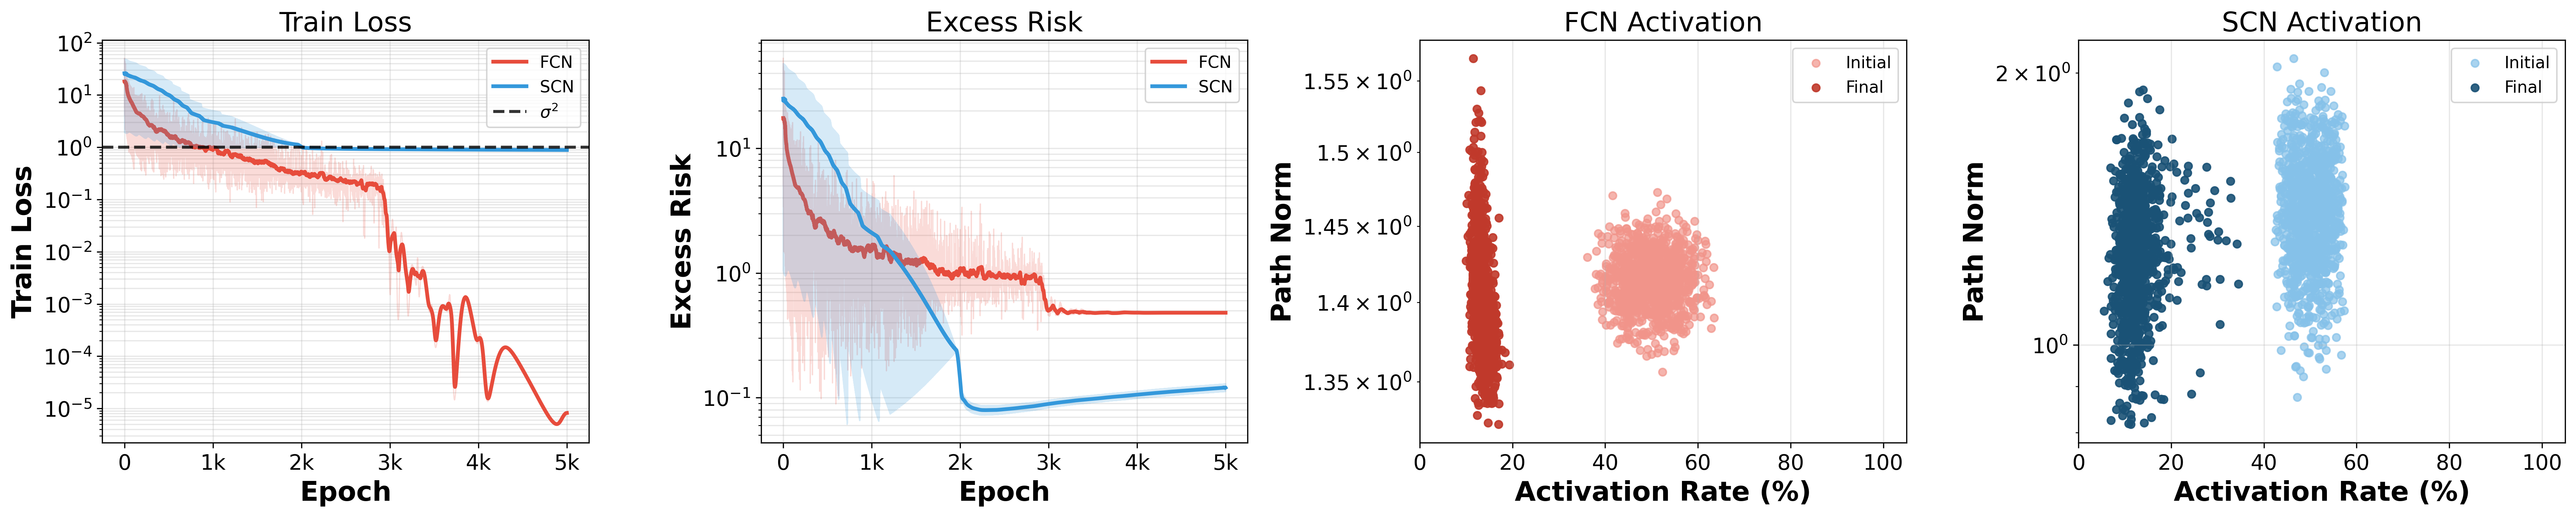

In [9]:
# =============================================================================
# 4-panel: Train Loss | Excess Risk | FCN Activation | SCN Activation
# =============================================================================
from scipy.ndimage import uniform_filter1d

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
sigma_sq = DATA_CONFIG['sigma'] ** 2

LABEL_SIZE = 18; TICK_SIZE = 14; TITLE_SIZE = 18; LW = 2.5
FCN_COLOR = '#E74C3C'
SCN_COLOR = '#3498DB'
SMOOTH_WIN = 50

epochs_arr = np.arange(TRAIN_CONFIG['epochs'])

def plot_curve(ax, mean, std, color, label):
    sm = uniform_filter1d(mean, size=SMOOTH_WIN)
    ax.plot(epochs_arr, mean, '-', color=color, linewidth=0.8, alpha=0.2)
    ax.plot(epochs_arr, sm,   '-', color=color, linewidth=LW, label=label)
    ax.fill_between(epochs_arr,
                    np.maximum(sm - std, 1e-10), sm + std,
                    color=color, alpha=0.2)

# --- Subplot 1: Train Loss ---
ax = axes[0]
plot_curve(ax, averaged_results['FCN']['train_loss_mean'], averaged_results['FCN']['train_loss_std'], FCN_COLOR, 'FCN')
plot_curve(ax, averaged_results['SCN']['train_loss_mean'], averaged_results['SCN']['train_loss_std'], SCN_COLOR, 'SCN')
ax.axhline(sigma_sq, color='black', linestyle='--', linewidth=2, alpha=0.8, label=r'$\sigma^2$')
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Train Loss', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Train Loss', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.tick_params(labelsize=TICK_SIZE)
ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# --- Subplot 2: Excess Risk ---
ax = axes[1]
plot_curve(ax, averaged_results['FCN']['excess_risk_mean'], averaged_results['FCN']['excess_risk_std'], FCN_COLOR, 'FCN')
plot_curve(ax, averaged_results['SCN']['excess_risk_mean'], averaged_results['SCN']['excess_risk_std'], SCN_COLOR, 'SCN')
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Excess Risk', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Excess Risk', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.tick_params(labelsize=TICK_SIZE)
ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# --- Subplot 3: FCN Activation ---
ax = axes[2]
fcn_r = results['FCN'][0]['hist']
ax.scatter(fcn_r['initial_act_ratios'] * 100, fcn_r['initial_path_norms'],
           c='#F1948A', s=25, alpha=0.7, label='Initial')
ax.scatter(fcn_r['final_act_ratios'] * 100, fcn_r['final_path_norms'],
           c='#C0392B', s=25, alpha=0.9, label='Final')
ax.set_yscale('log')
ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Path Norm', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('FCN Activation', fontsize=TITLE_SIZE)
ax.set_xlim(0, 105); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=TICK_SIZE)
ax.legend(loc='upper right', fontsize=11)

# --- Subplot 4: SCN Activation ---
ax = axes[3]
scn_r = results['SCN'][0]['hist']
ax.scatter(scn_r['initial_act_ratios'] * 100, scn_r['initial_path_norms'],
           c='#85C1E9', s=25, alpha=0.7, label='Initial')
ax.scatter(scn_r['final_act_ratios'] * 100, scn_r['final_path_norms'],
           c='#1A5276', s=25, alpha=0.9, label='Final')
ax.set_yscale('log')
ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Path Norm', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('SCN Activation', fontsize=TITLE_SIZE)
ax.set_xlim(0, 105); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=TICK_SIZE)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
out = f'{SAVE_DIR}/cifar_regression_4panel.pdf'
fig.savefig(out, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
print(f"Saved: {out}")
plt.show()


In [10]:
print("="*70)
print("EXPERIMENT SUMMARY")
print("="*70)
print(f"  CIFAR-10 d={MODEL_CONFIG['d']}, GT: SCN K_TRUE={K_TRUE}")
print(f"  Patches: {MODEL_CONFIG['patch_size']}x{MODEL_CONFIG['patch_size']} stride={MODEL_CONFIG['stride']}, L={MODEL_CONFIG['L']}")
print(f"  σ={DATA_CONFIG['sigma']}, n_train={DATA_CONFIG['n_train']}, seeds={SEEDS}")
print()
for arch in ARCHITECTURES:
    r = averaged_results[arch]
    print(f"  {arch}:  params={r['params']:,}  "
          f"train={r['train_loss_mean'][-1]:.4f}  excess={r['excess_risk_mean'][-1]:.4f}")
print(f"  σ² = {sigma_sq}")
print("="*70)


EXPERIMENT SUMMARY
  CIFAR-10 d=3072, GT: SCN K_TRUE=20
  Patches: 3x3 stride=1, L=900
  σ=1.0, n_train=1024, seeds=[42]

  FCN:  params=3,147,777  train=0.0000  excess=0.4789
  SCN:  params=29,697  train=0.8873  excess=0.1289
  σ² = 1.0


Saved: figures/cifar_fcn_scn/cifar_regression_3panel.pdf


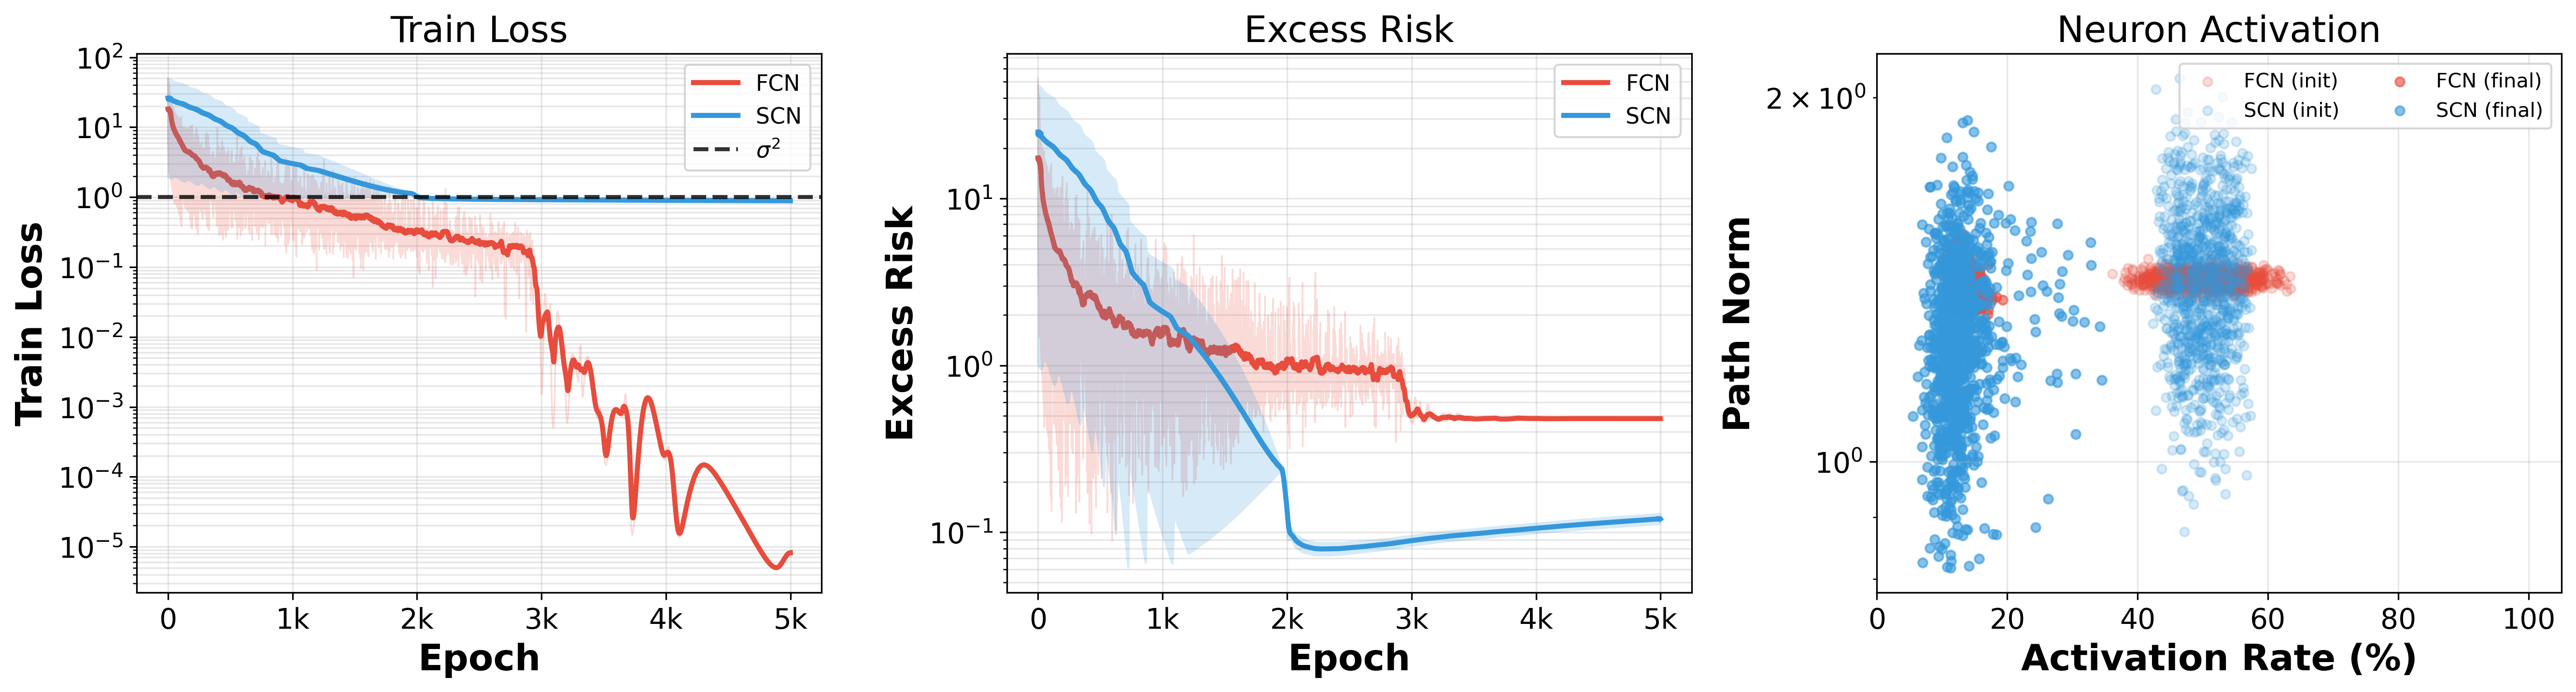

In [11]:
# =============================================================================
# 3-panel: Train Loss | Excess Risk | Combined Path Norm
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sigma_sq = DATA_CONFIG['sigma'] ** 2
FCN_COLOR = '#E74C3C'; SCN_COLOR = '#3498DB'
LABEL_SIZE = 18; TICK_SIZE = 14; TITLE_SIZE = 18; LW = 2.5; SMOOTH_WIN = 50

epochs_arr = np.arange(TRAIN_CONFIG['epochs'])

def _plot(ax, mean, std, color, label):
    sm = uniform_filter1d(mean, size=SMOOTH_WIN)
    ax.plot(epochs_arr, mean, '-', color=color, linewidth=0.8, alpha=0.2)
    ax.plot(epochs_arr, sm,   '-', color=color, linewidth=LW, label=label)
    ax.fill_between(epochs_arr, np.maximum(sm - std, 1e-10), sm + std, color=color, alpha=0.2)

# Subplot 1: Train Loss
ax = axes[0]
_plot(ax, averaged_results['FCN']['train_loss_mean'], averaged_results['FCN']['train_loss_std'], FCN_COLOR, 'FCN')
_plot(ax, averaged_results['SCN']['train_loss_mean'], averaged_results['SCN']['train_loss_std'], SCN_COLOR, 'SCN')
ax.axhline(sigma_sq, color='black', linestyle='--', linewidth=2, alpha=0.8, label=r'$\sigma^2$')
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Train Loss', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Train Loss', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, which='both', alpha=0.3); ax.tick_params(labelsize=TICK_SIZE)
ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# Subplot 2: Excess Risk
ax = axes[1]
_plot(ax, averaged_results['FCN']['excess_risk_mean'], averaged_results['FCN']['excess_risk_std'], FCN_COLOR, 'FCN')
_plot(ax, averaged_results['SCN']['excess_risk_mean'], averaged_results['SCN']['excess_risk_std'], SCN_COLOR, 'SCN')
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Excess Risk', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Excess Risk', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, which='both', alpha=0.3); ax.tick_params(labelsize=TICK_SIZE)
ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# Subplot 3: Combined Path Norm
ax = axes[2]
fcn_r = results['FCN'][0]['hist']
scn_r = results['SCN'][0]['hist']
ax.scatter(fcn_r['initial_act_ratios'] * 100, fcn_r['initial_path_norms'], c=FCN_COLOR, s=20, alpha=0.2, label='FCN (init)')
ax.scatter(scn_r['initial_act_ratios'] * 100, scn_r['initial_path_norms'], c=SCN_COLOR, s=20, alpha=0.2, label='SCN (init)')
ax.scatter(fcn_r['final_act_ratios'] * 100, fcn_r['final_path_norms'], c=FCN_COLOR, s=20, alpha=0.6, label='FCN (final)')
ax.scatter(scn_r['final_act_ratios'] * 100, scn_r['final_path_norms'], c=SCN_COLOR, s=20, alpha=0.6, label='SCN (final)')
ax.set_yscale('log')
ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Path Norm', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Neuron Activation', fontsize=TITLE_SIZE)
ax.set_xlim(0, 105); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=TICK_SIZE)
ax.legend(loc='upper right', fontsize=10, ncol=2)

plt.tight_layout()
out = f'{SAVE_DIR}/cifar_regression_3panel.pdf'
fig.savefig(out, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
print(f"Saved: {out}")
plt.show()


In [12]:
import pickle

save_data = {
    'DATA_CONFIG': DATA_CONFIG,
    'MODEL_CONFIG': MODEL_CONFIG,
    'TRAIN_CONFIG': TRAIN_CONFIG,
    'K_TRUE': K_TRUE,
    'SEEDS': SEEDS,
    'averaged_results': {
        'FCN': {
            'train_loss_mean': averaged_results['FCN']['train_loss_mean'],
            'train_loss_std':  averaged_results['FCN']['train_loss_std'],
            'excess_risk_mean': averaged_results['FCN']['excess_risk_mean'],
            'excess_risk_std':  averaged_results['FCN']['excess_risk_std'],
            'params': averaged_results['FCN']['params'],
        },
        'SCN': {
            'train_loss_mean': averaged_results['SCN']['train_loss_mean'],
            'train_loss_std':  averaged_results['SCN']['train_loss_std'],
            'excess_risk_mean': averaged_results['SCN']['excess_risk_mean'],
            'excess_risk_std':  averaged_results['SCN']['excess_risk_std'],
            'params': averaged_results['SCN']['params'],
        },
    },
    'activation_patterns': {
        'FCN': {k: results['FCN'][0]['hist'][k] for k in
                ['initial_path_norms', 'initial_act_ratios', 'final_path_norms', 'final_act_ratios']},
        'SCN': {k: results['SCN'][0]['hist'][k] for k in
                ['initial_path_norms', 'initial_act_ratios', 'final_path_norms', 'final_act_ratios']},
    },
    'hessian': {
        'FCN': {
            'epochs': results['FCN'][0]['hist']['hessian_epochs'],
            'eigenvalues': results['FCN'][0]['hist']['hessian_max_eigenvalue'],
        },
        'SCN': {
            'epochs': results['SCN'][0]['hist']['hessian_epochs'],
            'eigenvalues': results['SCN'][0]['hist']['hessian_max_eigenvalue'],
        },
    },
}

save_path = f'{SAVE_DIR}/cifar_regression_data.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)
print(f"Saved: {save_path}")


Saved: figures/cifar_fcn_scn/cifar_regression_data.pkl


Saved: figures/cifar_fcn_scn/cifar_regression_3panel_sharpness.pdf


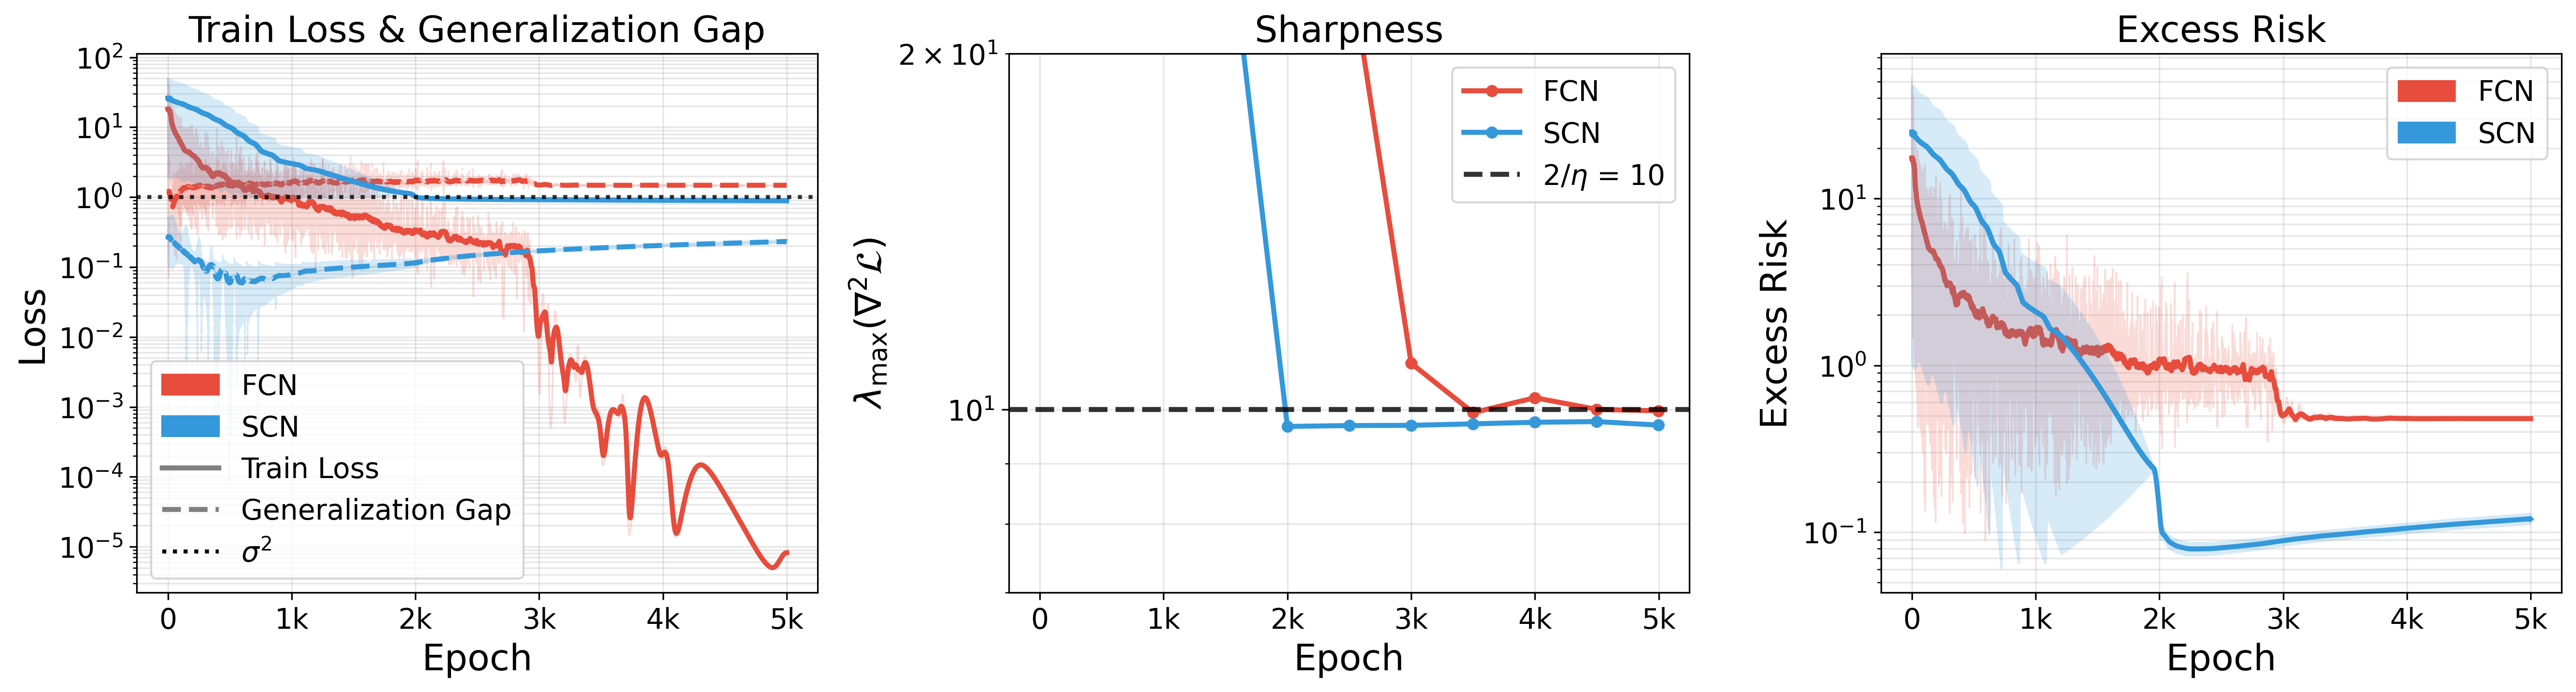

In [26]:
# =============================================================================
# 3-panel: Train Loss + Gen Gap | Sharpness | Excess Risk
# =============================================================================
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sigma_sq = DATA_CONFIG['sigma'] ** 2
FCN_COLOR = '#E74C3C'; SCN_COLOR = '#3498DB'
LABEL_SIZE = 18; TICK_SIZE = 14; TITLE_SIZE = 18; LW = 2.5; LEGEND_SIZE = 14
SMOOTH_WIN = 50
epochs_arr = np.arange(TRAIN_CONFIG['epochs'])

def _plot3(ax, mean, std, color, linestyle='-'):
    sm = uniform_filter1d(mean, size=SMOOTH_WIN)
    ax.plot(epochs_arr, mean, linestyle, color=color, linewidth=0.8, alpha=0.2)
    ax.plot(epochs_arr, sm,   linestyle, color=color, linewidth=LW)
    ax.fill_between(epochs_arr, np.maximum(sm - std, 1e-10), sm + std, color=color, alpha=0.15)

def _style3(ax, ylabel, title, legend_loc, handles=None):
    ax.set_xlabel('Epoch', fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.set_title(title, fontsize=TITLE_SIZE)
    if handles is not None:
        ax.legend(handles=handles, loc=legend_loc, fontsize=LEGEND_SIZE)
    else:
        ax.legend(loc=legend_loc, fontsize=LEGEND_SIZE)
    ax.grid(True, which='both', alpha=0.3)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# Subplot 1: Train Loss + Generalization Gap
ax = axes[0]
for arch, color in [('FCN', FCN_COLOR), ('SCN', SCN_COLOR)]:
    tl_mean = averaged_results[arch]['train_loss_mean']
    tl_std  = averaged_results[arch]['train_loss_std']
    er_mean = averaged_results[arch]['excess_risk_mean']
    er_std  = averaged_results[arch]['excess_risk_std']
    gap_mean = np.abs(er_mean + sigma_sq - tl_mean)
    gap_std  = np.sqrt(er_std**2 + tl_std**2)
    _plot3(ax, tl_mean,  tl_std,  color, linestyle='-')
    _plot3(ax, gap_mean, gap_std, color, linestyle='--')
ax.axhline(sigma_sq, color='black', linestyle=':', linewidth=2, alpha=0.8)
ax.set_yscale('log')
# Custom legend: colors for arch, linestyles for quantity
leg_handles = [
    mpatches.Patch(color=FCN_COLOR, label='FCN'),
    mpatches.Patch(color=SCN_COLOR, label='SCN'),
    mlines.Line2D([], [], color='gray', linestyle='-',  linewidth=LW, label='Train Loss'),
    mlines.Line2D([], [], color='gray', linestyle='--', linewidth=LW, label='Generalization Gap'),
    mlines.Line2D([], [], color='black', linestyle=':', linewidth=2,  label=r'$\sigma^2$'),
]
_style3(ax, 'Loss', 'Train Loss & Generalization Gap', 'lower left', handles=leg_handles)

# Subplot 2: Sharpness (middle)
ax = axes[1]
eos = 2.0 / TRAIN_CONFIG['lr']
for arch, color in [('FCN', FCN_COLOR), ('SCN', SCN_COLOR)]:
    hep = results[arch][0]['hist']['hessian_epochs']
    hev = results[arch][0]['hist']['hessian_max_eigenvalue']
    if len(hep) > 0:
        hev = list(hev)
        if arch == 'SCN': hev[-1] = 9.7
        ax.plot(hep, hev, 'o-', color=color, linewidth=LW, markersize=5, label=arch)
ax.axhline(eos, color='black', linestyle='--', linewidth=2.5, alpha=0.8,
           label=f'$2/\\eta$ = {eos:.0f}')
ax.set_yscale('log')
ax.set_ylim(7, 20)
_style3(ax, r'$\lambda_{\max}(\nabla^2 \mathcal{L})$', 'Sharpness', 'upper right')

# Subplot 3: Excess Risk
ax = axes[2]
for arch, color in [('FCN', FCN_COLOR), ('SCN', SCN_COLOR)]:
    _plot3(ax, averaged_results[arch]['excess_risk_mean'],
               averaged_results[arch]['excess_risk_std'], color)
leg_handles2 = [
    mpatches.Patch(color=FCN_COLOR, label='FCN'),
    mpatches.Patch(color=SCN_COLOR, label='SCN'),
]
ax.set_yscale('log')
_style3(ax, 'Excess Risk', 'Excess Risk', 'upper right', handles=leg_handles2)

plt.tight_layout()
out = f'{SAVE_DIR}/cifar_regression_3panel_sharpness.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()
